# NB02 — Baseline: ResNet-50

**Purpose**: Establish an end-to-end working pipeline and produce a first performance
number. The backbone is frozen; only the regression head is trained.

**Inputs**:
- `data/processed/bt_scores_augmented.csv` (produced by NB00)
- `outputs/split_assignment.csv` (produced by NB01)
- Reprojected JPEGs at `REPRO_ROOT / {intersection_id} / leg_{bearing:.0f}.jpeg`

**Outputs**:
- `features/resnet50/{sample_id}.pt` — cached feature vectors (one per sample)
- `outputs/resnet50_best.pt` — best model checkpoint
- `outputs/resnet50_metrics.json` — validation metrics (loaded by NB04)
- `outputs/nb02_training_curve.png`
- `outputs/nb02_residual_plot.png`

---

**Imports** — ML stack + standard libraries.

In [15]:
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from scipy import stats
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50

warnings.filterwarnings("ignore", category=UserWarning)

**Configuration** — All paths and hyperparameters are defined here as named constants.
Change values in this cell only; never hardcode paths or numbers further down.

| Hyperparameter | Value | Rationale |
|---|---|---|
| `LEARNING_RATE` | 1e-3 | Standard Adam default for small regression heads |
| `BATCH_SIZE` | 32 | Fits in RAM; large enough for stable gradient estimates |
| `DROPOUT` | 0.3 | Moderate regularisation; avoids overfitting on N=68 originals |
| `MAX_EPOCHS` | 200 | Upper bound; early stopping will usually trigger well before this |
| `PATIENCE` | 20 | ~10% of max epochs; allows the head to escape local minima |
| `HIDDEN_DIM` | 128 | Bottleneck between 2048-dim backbone and scalar output |

In [16]:
# ---------------------------------------------------------------------------
# EXPERIMENT FLAGS — toggle these to compare configurations
# ---------------------------------------------------------------------------

# Train on original samples only (ignore augmented copies).
# Augmented feature vectors are nearly identical to their source image's features
# because the backbone is frozen — they add correlated noise rather than diversity.
# Set True to train on 68 truly unique samples instead of 340 correlated ones.
USE_ORIGINALS_ONLY = True

# L2-normalise each feature vector to unit length before training.
# ResNet's 2048-dim output has uneven dimension magnitudes; normalising prevents
# a few dominant dimensions from controlling the regression head.
NORMALIZE_FEATURES = True

# Regression head architecture.
# "mlp"    : Linear(feat→hidden) → ReLU → Dropout → Linear(hidden→1) → Sigmoid
# "linear" : Linear(feat→1) → Sigmoid  (fewer parameters, less overfitting risk)
HEAD_TYPE = "linear"

# L2 weight decay for Adam. With only ~68 training intersections, regularisation
# is critical. 0 = no weight decay (original setting).
WEIGHT_DECAY = 1e-2

# ---------------------------------------------------------------------------
# BACKBONE
# ---------------------------------------------------------------------------
BACKBONE_NAME = "resnet50"
FEATURE_DIM   = 2048   # ResNet-50 penultimate layer output dimension

# ---------------------------------------------------------------------------
# REGRESSION HEAD HYPERPARAMETERS
# ---------------------------------------------------------------------------
HIDDEN_DIM    = 128
DROPOUT       = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 200
PATIENCE      = 20     # early stopping patience (epochs without val improvement)

# ---------------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------------
CV_ROOT      = Path("..")
REPRO_ROOT   = Path(r"D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_new")

BT_SCORES_CSV = CV_ROOT / "data" / "processed" / "bt_scores_augmented.csv"
SPLIT_CSV     = CV_ROOT / "outputs" / "split_assignment.csv"
FEATURES_DIR  = CV_ROOT / "features" / BACKBONE_NAME
OUTPUTS_DIR   = CV_ROOT / "outputs"
CHECKPOINT    = OUTPUTS_DIR / f"{BACKBONE_NAME}_best.pt"
METRICS_JSON  = OUTPUTS_DIR / f"{BACKBONE_NAME}_metrics.json"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"=== Experiment configuration ===")
print(f"USE_ORIGINALS_ONLY : {USE_ORIGINALS_ONLY}")
print(f"NORMALIZE_FEATURES : {NORMALIZE_FEATURES}")
print(f"HEAD_TYPE          : {HEAD_TYPE}")
print(f"WEIGHT_DECAY       : {WEIGHT_DECAY}")
print(f"DROPOUT            : {DROPOUT}  (only used when HEAD_TYPE='mlp')")
print(f"Device             : {device}")
print(f"REPRO_ROOT exists  : {REPRO_ROOT.exists()}")

=== Experiment configuration ===
USE_ORIGINALS_ONLY : True
NORMALIZE_FEATURES : True
HEAD_TYPE          : linear
WEIGHT_DECAY       : 0.01
DROPOUT            : 0.3  (only used when HEAD_TYPE='mlp')
Device             : cpu
REPRO_ROOT exists  : True


## 1. Load data

Merge the augmented BT scores with the split assignment from NB01. Filter out
intersections whose `leg_bearing` is NaN (5 intersections not present in sampled_legs
— no photo path can be constructed for them).

In [17]:
# Load both files and join on sample_id to attach cv_split to each row
bt    = pd.read_csv(BT_SCORES_CSV)
split = pd.read_csv(SPLIT_CSV)

df = bt.merge(split[["sample_id", "cv_split"]], on="sample_id", how="left")

# Intersections without leg_bearing cannot be mapped to a photo — skip them
no_bearing = df["leg_bearing"].isna()
if no_bearing.any():
    n = no_bearing.sum()
    ids = df.loc[no_bearing & ~df["is_augmented"], "intersection_id"].tolist()
    print(f"WARNING: dropping {n} rows with missing leg_bearing (intersection_ids: {ids})")
    df = df[~no_bearing].copy()

# Separate into train and val — only these two splits are used for model training
train_df = df[df["cv_split"] == "train"].reset_index(drop=True)
val_df   = df[df["cv_split"] == "val"].reset_index(drop=True)

# Optionally restrict training to original samples only (no augmented copies).
# With a frozen backbone the feature vectors of augmented copies are very similar
# to their source image, so they add correlated rather than independent information.
if USE_ORIGINALS_ONLY:
    train_df = train_df[~train_df["is_augmented"]].reset_index(drop=True)
    print("USE_ORIGINALS_ONLY=True — keeping original training samples only.")

print(f"Train samples : {len(train_df)}  "
      f"(originals: {(~train_df['is_augmented']).sum()}, "
      f"augmented: {train_df['is_augmented'].sum()})")
print(f"Val samples   : {len(val_df)}  (originals only, no augmented copies)")

USE_ORIGINALS_ONLY=True — keeping original training samples only.
Train samples : 64  (originals: 64, augmented: 0)
Val samples   : 16  (originals only, no augmented copies)


## 2. Transforms and dataset

Two transforms are defined:
- **Training transform**: random crop, horizontal flip, colour jitter, Gaussian blur.
  Applied to all training samples (originals and augmented copies), seeded per-sample
  with `aug_seed` so the augmentation is reproducible and baked into the feature cache.
- **Validation transform**: deterministic resize only. Applied to val samples.

No vertical flips or large rotations — intersection photos have a fixed perspective
and sky/road orientation is semantically meaningful.

In [18]:
# ImageNet normalisation statistics (used for all torchvision pretrained backbones)
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])


class IntersectionDataset(Dataset):
    """Loads reprojected JPEGs from disk and applies a transform.

    Training samples are seeded with aug_seed so the random transform is
    reproducible — the same seed always produces the same crop/flip/jitter,
    which is what gets cached as a feature vector.
    """

    def __init__(self, df, repro_root, train_transform, val_transform):
        self.df              = df.reset_index(drop=True)
        self.repro_root      = Path(repro_root)
        self.train_transform = train_transform
        self.val_transform   = val_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        iid      = int(row["intersection_id"])
        bearing  = float(row["leg_bearing"]) % 360  # guard against 360.0
        aug_seed = int(row["aug_seed"])
        is_val   = row["cv_split"] == "val"

        path = self.repro_root / str(iid) / f"leg_{bearing:.0f}.jpeg"
        img  = Image.open(path).convert("RGB")

        if is_val:
            # Deterministic transform — no seeding needed
            img_tensor = self.val_transform(img)
        else:
            # Seed both Python random and PyTorch so all stochastic ops are reproducible
            random.seed(aug_seed)
            torch.manual_seed(aug_seed)
            img_tensor = self.train_transform(img)

        return img_tensor, str(row["sample_id"]), float(row["bt_score"])


print("IntersectionDataset defined.")
print(f"Training transform : {len(train_transform.transforms)} steps")
print(f"Val transform      : {len(val_transform.transforms)} steps")

IntersectionDataset defined.
Training transform : 7 steps
Val transform      : 3 steps


## 3. Feature extraction (ResNet-50, frozen)

Load the pretrained ResNet-50 and replace its classification head (`fc`) with
`nn.Identity()` so the backbone outputs a 2048-dim feature vector. All backbone
weights are frozen.

Features are extracted once per sample and cached to `features/resnet50/{sample_id}.pt`.
Subsequent runs skip samples whose cache file already exists.

In [19]:
# Load pretrained ResNet-50 (ImageNet1K V2 weights) and freeze it
backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
backbone.fc = nn.Identity()  # output is now 2048-dim instead of 1000-dim
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()
backbone.to(device)

n_params = sum(p.numel() for p in backbone.parameters())
print(f"ResNet-50 loaded  : {n_params/1e6:.1f}M params (all frozen)")

ResNet-50 loaded  : 23.5M params (all frozen)


In [20]:
# Combine train and val rows so we extract features for everything in one pass
all_df  = pd.concat([train_df, val_df], ignore_index=True)
all_ds  = IntersectionDataset(all_df, REPRO_ROOT, train_transform, val_transform)

print(f"Total samples to process : {len(all_ds)}")
already_cached = sum(1 for _, row in all_df.iterrows()
                     if (FEATURES_DIR / f"{row['sample_id']}.pt").exists())
print(f"Already cached           : {already_cached}")
print(f"To extract               : {len(all_ds) - already_cached}")

Total samples to process : 80
Already cached           : 79
To extract               : 1


In [21]:
@torch.no_grad()
def extract_and_cache(dataset, df, backbone, features_dir, device):
    """Run each image through the frozen backbone and save the feature vector.

    Skips samples whose .pt file already exists so re-running is fast.
    """
    backbone.eval()
    skipped  = 0
    extracted = 0
    errors   = []

    for idx in range(len(dataset)):
        sample_id  = df.iloc[idx]["sample_id"]
        cache_path = features_dir / f"{sample_id}.pt"

        if cache_path.exists():
            skipped += 1
            continue

        try:
            img_tensor, _, _ = dataset[idx]
            feat = backbone(img_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            torch.save(feat, cache_path)
            extracted += 1
        except Exception as e:
            errors.append((sample_id, str(e)))

        # Progress indicator every 50 samples
        if (skipped + extracted) % 50 == 0 and (skipped + extracted) > 0:
            print(f"  processed {skipped + extracted}/{len(dataset)} ...", flush=True)

    print(f"Done. Reused: {skipped}  |  Extracted: {extracted}  |  Errors: {len(errors)}")
    if errors:
        for sid, err in errors:
            print(f"  ERROR {sid}: {err}")
    return errors


errors = extract_and_cache(all_ds, all_df, backbone, FEATURES_DIR, device)

Done. Reused: 79  |  Extracted: 0  |  Errors: 1
  ERROR 185273145_orig: [Errno 2] No such file or directory: 'D:\\rotterdam_aiis_2025\\vault-production\\vault_v1\\reprojected_directional_fov90_dist20_new\\185273145\\leg_217.jpeg'


## 4. Training

The `FeatureDataset` loads pre-extracted `.pt` tensors from disk — no image I/O during
training. The regression head is trained with MSE loss and Adam optimiser. Early
stopping saves the checkpoint with the lowest validation MSE.

In [22]:
class FeatureDataset(Dataset):
    """Reads cached .pt feature tensors from disk and pairs them with BT scores.

    If NORMALIZE_FEATURES=True, each vector is L2-normalised to unit length.
    Normalisation is applied at load time so the raw cache files are never modified
    and the flag can be toggled without re-extracting features.
    """

    def __init__(self, df, features_dir, normalize=False):
        self.records = [
            (str(row["sample_id"]), float(row["bt_score"]))
            for _, row in df.iterrows()
            if (Path(features_dir) / f"{row['sample_id']}.pt").exists()
        ]
        self.features_dir = Path(features_dir)
        self.normalize    = normalize
        if len(self.records) < len(df):
            print(f"WARNING: {len(df) - len(self.records)} samples missing feature cache — skipped.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        sample_id, bt_score = self.records[idx]
        feat  = torch.load(self.features_dir / f"{sample_id}.pt", weights_only=True)
        if self.normalize:
            feat = feat / (feat.norm() + 1e-8)  # L2 normalise to unit sphere
        label = torch.tensor(bt_score, dtype=torch.float32)
        return feat, label


train_ds = FeatureDataset(train_df, FEATURES_DIR, normalize=NORMALIZE_FEATURES)
val_ds   = FeatureDataset(val_df,   FEATURES_DIR, normalize=NORMALIZE_FEATURES)

# num_workers=0 avoids multiprocessing issues on Windows
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train dataset : {len(train_ds)} samples  ({len(train_loader)} batches)")
print(f"Val dataset   : {len(val_ds)} samples")
print(f"Normalize features : {NORMALIZE_FEATURES}")

Train dataset : 63 samples  (2 batches)
Val dataset   : 16 samples
Normalize features : True


In [23]:
class RegressionHead(nn.Module):
    """Maps backbone features to a safety score in [0, 1].

    HEAD_TYPE='mlp'    : two-layer MLP with ReLU + Dropout between layers.
    HEAD_TYPE='linear' : single linear projection — fewer parameters, less
                         overfitting risk when training intersections are few.
    """

    def __init__(self, input_dim, head_type="mlp", hidden_dim=128, dropout=0.3):
        super().__init__()
        if head_type == "linear":
            self.net = nn.Sequential(
                nn.Linear(input_dim, 1),
                nn.Sigmoid(),
            )
        else:  # "mlp"
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid(),
            )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (B,) not (B, 1)


model     = RegressionHead(FEATURE_DIM, head_type=HEAD_TYPE,
                           hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
# Weight decay adds L2 penalty to all parameters — critical regularisation
# when the number of training intersections is small.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters())
print(f"Head type       : {HEAD_TYPE}")
print(f"Trainable params: {n_params:,}")
print(f"Weight decay    : {WEIGHT_DECAY}")

Head type       : linear
Trainable params: 2,049
Weight decay    : 0.01


In [24]:
train_losses = []
val_losses   = []
best_val_mse = float("inf")
patience_ctr  = 0
best_epoch    = 0

for epoch in range(MAX_EPOCHS):
    # --- Training pass ---
    model.train()
    running_loss = 0.0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(feats)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(labels)
    train_mse = running_loss / len(train_ds)
    train_losses.append(train_mse)

    # --- Validation pass ---
    model.eval()
    with torch.no_grad():
        val_running = 0.0
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            preds = model(feats)
            val_running += criterion(preds, labels).item() * len(labels)
    val_mse = val_running / len(val_ds)
    val_losses.append(val_mse)

    # --- Early stopping: save checkpoint on improvement ---
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), CHECKPOINT)
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 20 == 0 or patience_ctr == 0:
        marker = " ← best" if patience_ctr == 0 else ""
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | train MSE={train_mse:.4f} | val MSE={val_mse:.4f}{marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1} (best was epoch {best_epoch}).")
        break

print(f"\nBest val MSE : {best_val_mse:.4f}  (epoch {best_epoch})")
print(f"Checkpoint   : {CHECKPOINT}")

Epoch   1/200 | train MSE=0.0746 | val MSE=0.0841 ← best
Epoch   2/200 | train MSE=0.0728 | val MSE=0.0816 ← best
Epoch   3/200 | train MSE=0.0710 | val MSE=0.0793 ← best
Epoch   4/200 | train MSE=0.0691 | val MSE=0.0771 ← best
Epoch   5/200 | train MSE=0.0676 | val MSE=0.0750 ← best
Epoch   6/200 | train MSE=0.0660 | val MSE=0.0731 ← best
Epoch   7/200 | train MSE=0.0645 | val MSE=0.0713 ← best
Epoch   8/200 | train MSE=0.0633 | val MSE=0.0697 ← best
Epoch   9/200 | train MSE=0.0620 | val MSE=0.0681 ← best
Epoch  10/200 | train MSE=0.0608 | val MSE=0.0667 ← best
Epoch  11/200 | train MSE=0.0598 | val MSE=0.0655 ← best
Epoch  12/200 | train MSE=0.0588 | val MSE=0.0644 ← best
Epoch  13/200 | train MSE=0.0580 | val MSE=0.0633 ← best
Epoch  14/200 | train MSE=0.0573 | val MSE=0.0624 ← best
Epoch  15/200 | train MSE=0.0565 | val MSE=0.0615 ← best
Epoch  16/200 | train MSE=0.0558 | val MSE=0.0608 ← best
Epoch  17/200 | train MSE=0.0552 | val MSE=0.0602 ← best
Epoch  18/200 | train MSE=0.054

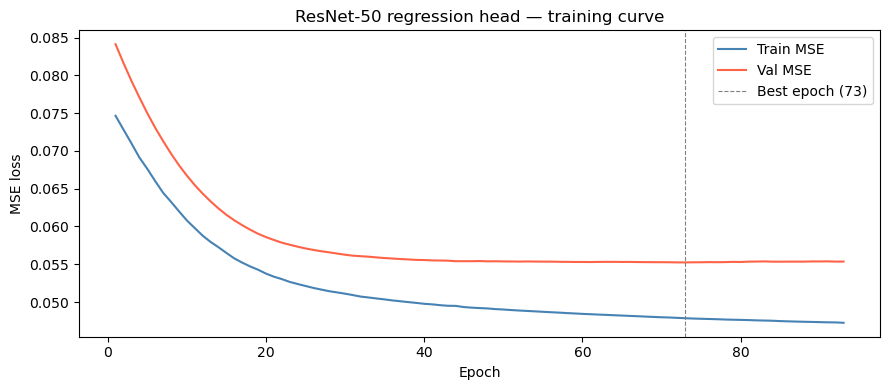

Training curve saved.


In [25]:
# Plot training and validation MSE curves
fig, ax = plt.subplots(figsize=(9, 4))
epochs_range = range(1, len(train_losses) + 1)

ax.plot(epochs_range, train_losses, label="Train MSE", color="steelblue")
ax.plot(epochs_range, val_losses,   label="Val MSE",   color="tomato")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=0.8,
           label=f"Best epoch ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title(f"ResNet-50 regression head — training curve")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb02_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curve saved.")

## 5. Validation metrics

Load the best checkpoint and compute four metrics on the val set:
- **MAE** / **RMSE** — absolute error in BT score units
- **R²** — variance explained
- **Spearman ρ** — rank correlation (important because BT scores derive from pairwise rankings)

Also report the **null model baseline** (predicting the training mean for every
intersection). A model that does not beat this baseline is not useful.

In [26]:
# Load best checkpoint and collect predictions on the val set
model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
model.eval()

all_preds  = []
all_labels = []
all_ids    = []

with torch.no_grad():
    for feats, labels in val_loader:
        preds = model(feats.to(device)).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

# Also collect val intersection_ids for the residual analysis below
all_ids = val_df["intersection_id"].tolist()[:len(all_preds)]  # guard against feature-missing rows

preds_arr  = np.array(all_preds)
labels_arr = np.array(all_labels)

# Model metrics
mae      = float(np.mean(np.abs(preds_arr - labels_arr)))
rmse     = float(np.sqrt(np.mean((preds_arr - labels_arr) ** 2)))
r2       = float(r2_score(labels_arr, preds_arr))
spear_r, spear_p = stats.spearmanr(preds_arr, labels_arr)

# Null model baseline: always predict the training-set mean
train_mean = float(train_df["bt_score"].mean())
null_mae   = float(np.mean(np.abs(labels_arr - train_mean)))
null_rmse  = float(np.sqrt(np.mean((labels_arr - train_mean) ** 2)))

print("=" * 55)
print(f"{'Metric':<20} {'ResNet-50':>12} {'Null model':>12}")
print("-" * 55)
print(f"{'MAE':<20} {mae:>12.4f} {null_mae:>12.4f}")
print(f"{'RMSE':<20} {rmse:>12.4f} {null_rmse:>12.4f}")
print(f"{'R²':<20} {r2:>12.4f} {'—':>12}")
print(f"{'Spearman ρ':<20} {spear_r:>12.4f} {'—':>12}")
print(f"{'Spearman p-value':<20} {spear_p:>12.4f} {'—':>12}")
print("=" * 55)

beats_null = mae < null_mae
print(f"\nBeats null model on MAE: {'YES' if beats_null else 'NO — model not useful yet'}")

Metric                  ResNet-50   Null model
-------------------------------------------------------
MAE                        0.1889       0.1752
RMSE                       0.2350       0.2347
R²                        -0.0080            —
Spearman ρ                 0.3912            —
Spearman p-value           0.1341            —

Beats null model on MAE: NO — model not useful yet


## 6. Residual analysis

Scatter plot of predicted vs actual BT scores. Points far from the diagonal indicate
high-error intersections — flagged for inspection to check whether errors cluster
by stratum or geography.

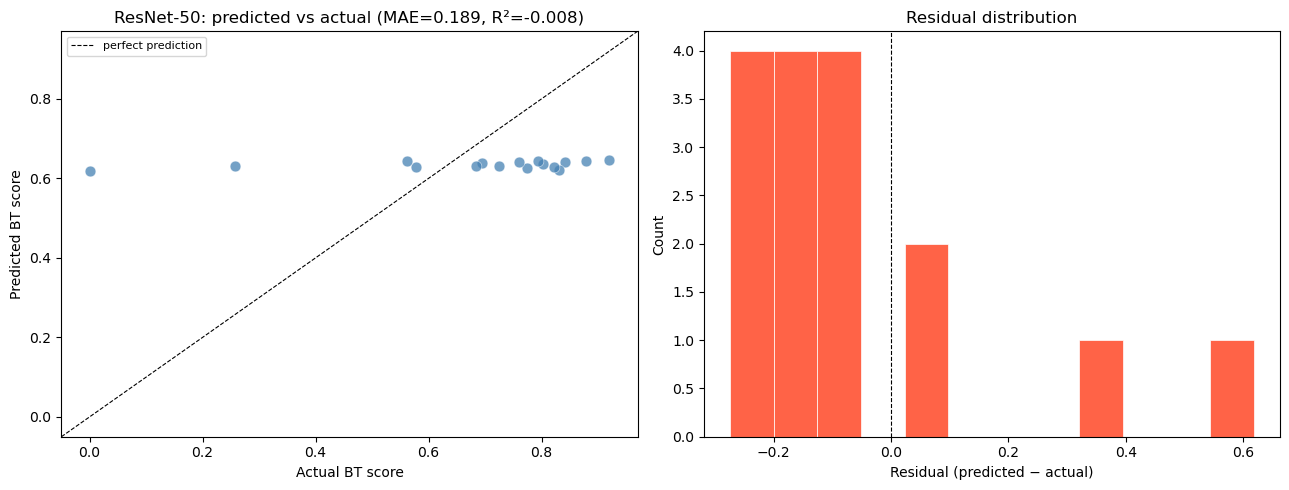


High-error intersections (|residual| > 0.2):
  183264037  pred=0.646  actual=0.920  resid=-0.274  dim_type=T  is_centrum=False
  189267114  pred=0.643  actual=0.878  resid=-0.235  dim_type=4+  is_centrum=False
  183263018  pred=0.640  actual=0.842  resid=-0.201  dim_type=4+  is_centrum=False
  187271099  pred=0.621  actual=0.830  resid=-0.209  dim_type=T  is_centrum=False
  186275130  pred=0.632  actual=0.257  resid=+0.375  dim_type=4+  is_centrum=False
  180271187  pred=0.618  actual=0.000  resid=+0.618  dim_type=4+  is_centrum=False


In [27]:
residuals = preds_arr - labels_arr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: predicted vs actual ---
ax = axes[0]
ax.scatter(labels_arr, preds_arr, alpha=0.75, edgecolors="white", linewidths=0.4,
           color="steelblue", s=60)
lims = [min(labels_arr.min(), preds_arr.min()) - 0.05,
        max(labels_arr.max(), preds_arr.max()) + 0.05]
ax.plot(lims, lims, "k--", linewidth=0.8, label="perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual BT score")
ax.set_ylabel("Predicted BT score")
ax.set_title(f"ResNet-50: predicted vs actual (MAE={mae:.3f}, R²={r2:.3f})")
ax.legend(fontsize=8)

# --- Right: residual histogram ---
ax2 = axes[1]
ax2.hist(residuals, bins=12, color="tomato", edgecolor="white", linewidth=0.5)
ax2.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Residual (predicted − actual)")
ax2.set_ylabel("Count")
ax2.set_title("Residual distribution")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb02_residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag high-error intersections (|residual| > 0.2)
ERROR_THRESHOLD = 0.2
high_err_mask = np.abs(residuals) > ERROR_THRESHOLD
if high_err_mask.any():
    print(f"\nHigh-error intersections (|residual| > {ERROR_THRESHOLD}):")
    for iid, pred, actual, resid in zip(
        np.array(all_ids)[high_err_mask],
        preds_arr[high_err_mask],
        labels_arr[high_err_mask],
        residuals[high_err_mask],
    ):
        row = val_df[val_df["intersection_id"] == iid].iloc[0]
        print(f"  {iid}  pred={pred:.3f}  actual={actual:.3f}  resid={resid:+.3f}  "
              f"dim_type={row.get('dim_type','?')}  is_centrum={row.get('is_centrum','?')}")
else:
    print(f"No intersections with |residual| > {ERROR_THRESHOLD}.")

## 7. Save artefacts

Metrics are saved as JSON so NB04 can load them without re-running training.

In [28]:
metrics = {
    "backbone"         : BACKBONE_NAME,
    "n_train"          : len(train_ds),
    "n_val"            : len(val_ds),
    "best_epoch"       : best_epoch,
    "best_val_mse"     : best_val_mse,
    "mae"              : mae,
    "rmse"             : rmse,
    "r2"               : r2,
    "spearman_r"       : float(spear_r),
    "spearman_p"       : float(spear_p),
    "null_mae"         : null_mae,
    "null_rmse"        : null_rmse,
    "train_mean_score" : train_mean,
    "experiment_flags" : {
        "use_originals_only" : USE_ORIGINALS_ONLY,
        "normalize_features" : NORMALIZE_FEATURES,
        "head_type"          : HEAD_TYPE,
        "weight_decay"       : WEIGHT_DECAY,
    },
    "hyperparameters"  : {
        "feature_dim"   : FEATURE_DIM,
        "hidden_dim"    : HIDDEN_DIM,
        "dropout"       : DROPOUT,
        "learning_rate" : LEARNING_RATE,
        "batch_size"    : BATCH_SIZE,
        "max_epochs"    : MAX_EPOCHS,
        "patience"      : PATIENCE,
    },
}

with open(METRICS_JSON, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to : {METRICS_JSON}")
print(f"Checkpoint at    : {CHECKPOINT}")

Metrics saved to : ..\outputs\resnet50_metrics.json
Checkpoint at    : ..\outputs\resnet50_best.pt


## Summary

| | |
|---|---|
| Backbone | ResNet-50 (frozen, ImageNet1K V2 weights) |
| Feature dim | 2048 |
| Training samples | *[fill from output]* |
| Val samples | *[fill from output]* |
| Best epoch | *[fill from output]* |
| Val MAE | *[fill from output]* |
| Val RMSE | *[fill from output]* |
| R² | *[fill from output]* |
| Spearman ρ | *[fill from output]* |
| Null model MAE | *[fill from output]* |
| Beats null? | *[fill from output]* |

**Next**: run NB03 (DINOv2-Small) with the same structure and compare metrics in NB04.